<a href="https://colab.research.google.com/github/Radheyaaa/colab-assignments/blob/main/DataMining-Clustering_Dataset_1_Mall_Customer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

| | |
|---|---|
| **Anggota 1** | Gede Soma Saputra / 2415091076 |
| **Anggota 2** | I Gede Radheya Devananda / 2415091105 |
| **Kelas** | SI 4A |
| **Dataset** | https://www.kaggle.com/datasets/kandij/mall-customers |

In [ ]:
!pip install kneed

## Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.cluster import KMeans, AgglomerativeClustering       # Import modul untuk K-Means dan Agglomerative Clustering
from sklearn.preprocessing import StandardScaler                  # Import modul untuk scaling fitur (StandardScaler)
from sklearn.metrics import silhouette_score, silhouette_samples  # Import metrik untuk evaluasi klaster (Silhouette Score)
from scipy.cluster.hierarchy import dendrogram, linkage           # Import fungsi untuk membuat dendrogram pada Agglomerative Clustering
from kneed import KneeLocator                                     # Import KneeLocator untuk deteksi titik siku (elbow point) secara otomatis

## Load Dataset


In [ ]:
# Memuat dataset dari file CSV ke dalam DataFrame pandas
df = pd.read_csv('Mall_Customers.csv')

# Menampilkan dimensi (jumlah baris dan kolom) dari DataFrame
print("Shape:", df.shape)
df.head(10)

Shape: (200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Preprocessing

**Fitur yang digunakan:** `Annual Income (k$)` dan `Spending Score (1-100)`  
Dua fitur ini paling representatif untuk segmentasi perilaku pelanggan.

In [ ]:
# 1. Seleksi fitur yang akan digunakan untuk clustering
features = ['Annual Income (k$)', 'Spending Score (1-100)']
# Mengambil nilai-nilai dari fitur yang dipilih
X = df[features].values
print("Fitur yang digunakan :", features)

# 2. Cek missing values pada fitur yang dipilih
print("\nMissing values per kolom:")
print(df[features].isnull().sum())

# 3. Feature Scaling (Standardisasi)
# Inisialisasi StandardScaler
scaler = StandardScaler()
# Melakukan fit dan transform data untuk menstandardisasi fitur
X_scaled = scaler.fit_transform(X)

Fitur yang digunakan : ['Annual Income (k$)', 'Spending Score (1-100)']

Missing values per kolom:
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


## Menentukan K Optimal — Elbow Method

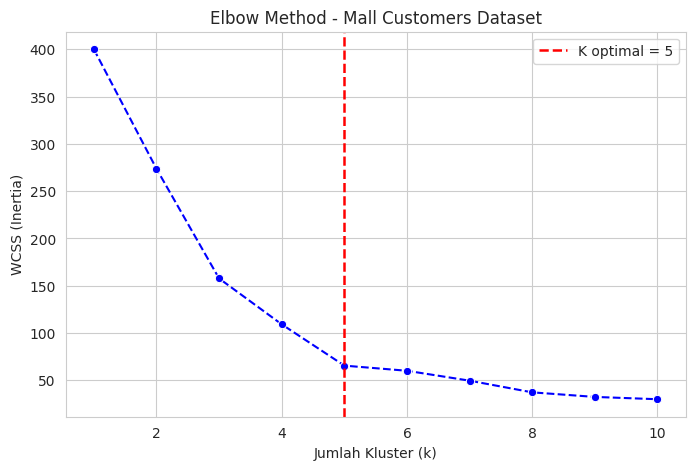

In [ ]:
# Inisialisasi list untuk menyimpan Within-Cluster Sum of Squares (WCSS)
wcss = []
# Rentang jumlah kluster (K) yang akan diuji, dari 1 hingga 10
K_range = range(1, 11)

# Melakukan iterasi untuk setiap nilai K dalam rentang K_range
for k in K_range:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Deteksi elbow point secara otomatis menggunakan KneeLocator
kl = KneeLocator(list(K_range), wcss, curve="convex", direction="decreasing")
k_optimal_elbow = kl.elbow

sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))
sns.lineplot(x=list(K_range), y=wcss, marker="o", linestyle="--", color="b")
plt.axvline(x=k_optimal_elbow, color='r', linestyle='--', linewidth=1.8,
            label=f'K optimal = {k_optimal_elbow}')
plt.xlabel("Jumlah Kluster (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method - Mall Customers Dataset")
plt.legend()
plt.show()

## Menentukan K Optimal - Silhouette Score

K Optimal (Silhouette Score) : 5
Silhouette Score tertinggi   : 0.5547


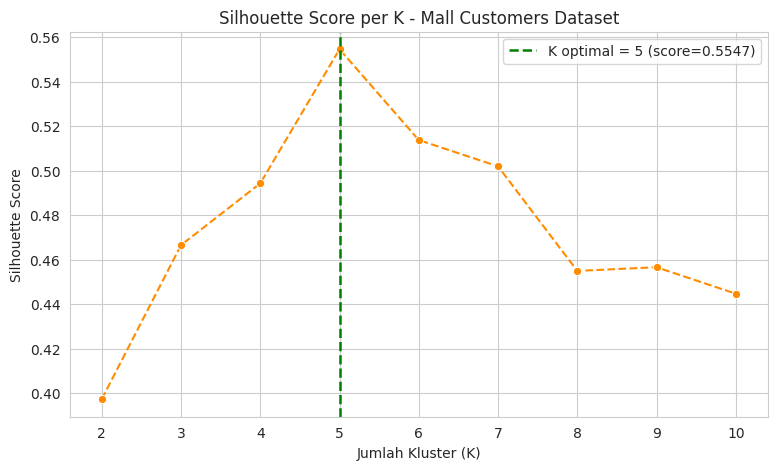

In [ ]:
# Inisialisasi list untuk menyimpan Silhouette Scores
sil_scores = []
# Rentang jumlah kluster (K) yang akan diuji, dari 2 hingga 10 (Silhouette Score tidak bisa untuk K=1)
K_range2 = range(2, 11)

# Melakukan iterasi untuk setiap nilai K dalam rentang K_range2
for k in K_range2:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Menemukan K optimal berdasarkan Silhouette Score tertinggi
best_k_sil = list(K_range2)[sil_scores.index(max(sil_scores))]
print(f"K Optimal (Silhouette Score) : {best_k_sil}")
print(f"Silhouette Score tertinggi   : {max(sil_scores):.4f}")


sns.set_style("whitegrid")
plt.figure(figsize=(9, 5))
sns.lineplot(x=list(K_range2), y=sil_scores, marker="o",linestyle="--", color="darkorange")
plt.axvline(x=best_k_sil, color='green', linestyle='--', linewidth=1.8,
    label=f'K optimal = {best_k_sil} (score={max(sil_scores):.4f})'
)

plt.xlabel("Jumlah Kluster (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score per K - Mall Customers Dataset")
plt.legend()
plt.show()

In [ ]:
# Menampilkan ringkasan hasil penentuan K optimal dari kedua metode
print("=" * 45)
print(f"Elbow Method    → K optimal = {k_optimal_elbow}")
print(f"Silhouette Score → K optimal = {best_k_sil}")
print("=" * 45)
# Menentukan nilai K final berdasarkan konsensus dari kedua metode
k_final = 5
print(f"K final yang digunakan = {k_final}")

Elbow Method    → K optimal = 5
Silhouette Score → K optimal = 5
K final yang digunakan = 5


## K-Means Clustering (K=5)

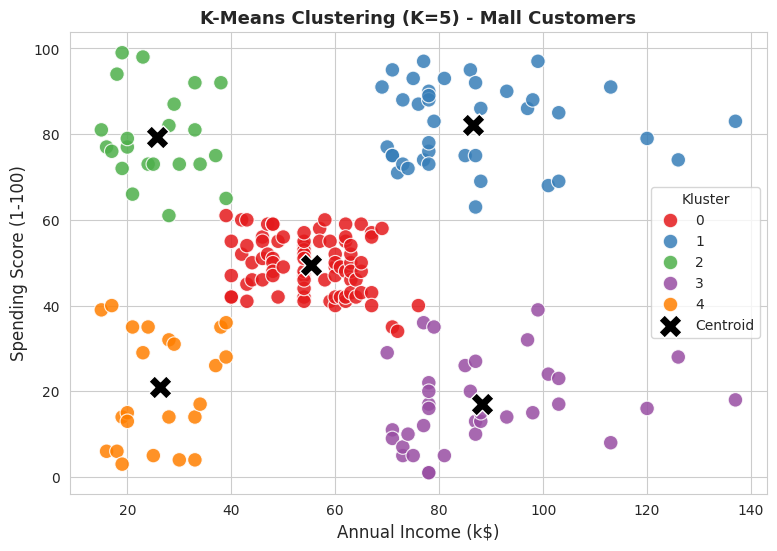

In [ ]:
# Inisialisasi model K-Means terakhir dengan K optimal (k_final)
kmeans_final = KMeans(n_clusters=k_final, n_init='auto', random_state=42)
# Melatih model K-Means dan menetapkan label kluster ke DataFrame
df['KMeans_Cluster'] = kmeans_final.fit_predict(X_scaled)

centroids_scaled = kmeans_final.cluster_centers_
centroids_orig = scaler.inverse_transform(centroids_scaled)


palette = sns.color_palette("Set1", k_final)
sns.set_style("whitegrid")

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='KMeans_Cluster', palette=palette, s=110, alpha=0.85)
plt.scatter(centroids_orig[:, 0], centroids_orig[:, 1], marker='X', s=280, color='black', edgecolor='white', label='Centroid', zorder=5)

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title(f'K-Means Clustering (K={k_final}) - Mall Customers', fontsize=13,fontweight='bold')
plt.legend(title='Kluster')
plt.show()

In [ ]:
# Menampilkan rata-rata fitur (Annual Income, Spending Score, Age) untuk setiap kluster K-Means
print("Rata-rata Fitur per Kluster (K-Means)")
summary = df.groupby('KMeans_Cluster')[features + ['Age']].mean().round(2)
summary['Jumlah'] = df.groupby('KMeans_Cluster').size()
print(summary)

Rata-rata Fitur per Kluster (K-Means)
                Annual Income (k$)  Spending Score (1-100)    Age  Jumlah
KMeans_Cluster                                                           
0                            55.30                   49.52  42.72      81
1                            86.54                   82.13  32.69      39
2                            25.73                   79.36  25.27      22
3                            88.20                   17.11  41.11      35
4                            26.30                   20.91  45.22      23


## Agglomerative Clustering

1. Dendogram

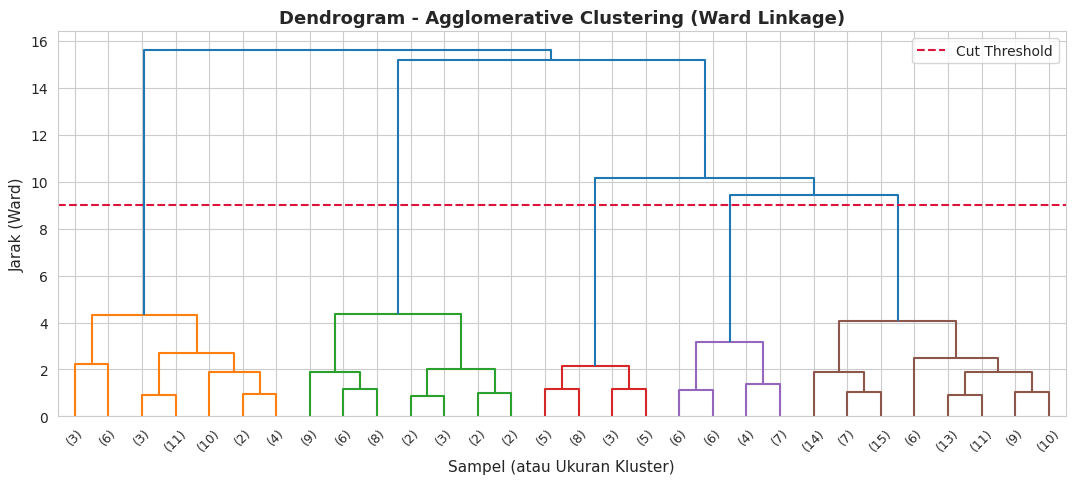

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(13, 5))

# Melakukan linkage pada data yang sudah diskalakan menggunakan metode 'ward'
# 'ward' meminimalkan varians intra-cluster
Z = linkage(X_scaled, method='ward')

# Membuat dendrogram dari hasil linkage
# truncate_mode='lastp' untuk hanya menampilkan 'p' kluster terakhir
# p=30 menunjukkan 30 kluster terakhir sebelum penggabungan
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=45, leaf_font_size=9, color_threshold=9)

plt.axhline(y=9, color='crimson', linestyle='--', linewidth=1.5, label='Cut Threshold')
plt.title('Dendrogram - Agglomerative Clustering (Ward Linkage)', fontsize=13, fontweight='bold')
plt.xlabel('Sampel (atau Ukuran Kluster)', fontsize=11)
plt.ylabel('Jarak (Ward)', fontsize=11)
plt.legend()
plt.show()

2. Fit Model Agglomerative

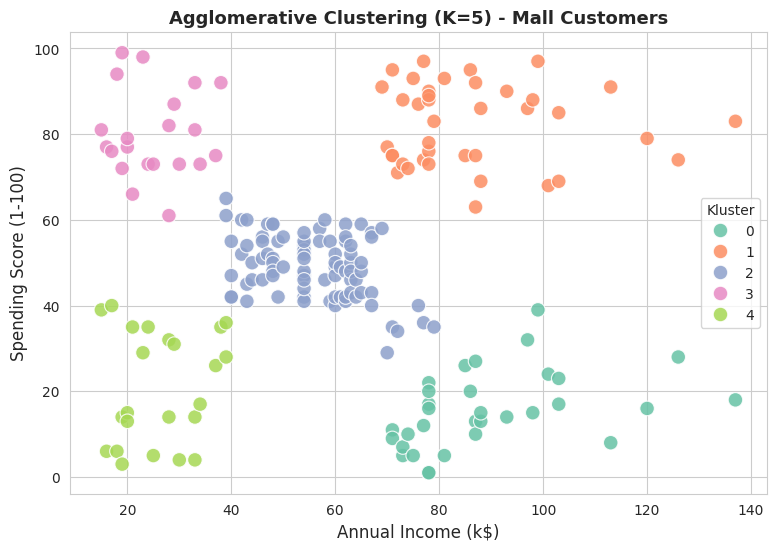

In [ ]:
# Inisialisasi model Agglomerative Clustering dengan K optimal (k_final) dan metode 'ward'
agglo = AgglomerativeClustering(n_clusters=k_final, linkage='ward')
df['Agglo_Cluster'] = agglo.fit_predict(X_scaled)

sns.set_style("whitegrid")
palette2 = sns.color_palette("Set2", k_final)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Agglo_Cluster', palette=palette2, s=110, alpha=0.85)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title(f'Agglomerative Clustering (K={k_final}) - Mall Customers', fontsize=13, fontweight='bold')
plt.legend(title='Kluster')
plt.show()

## Perbandingan K-Means vs Agglomerative

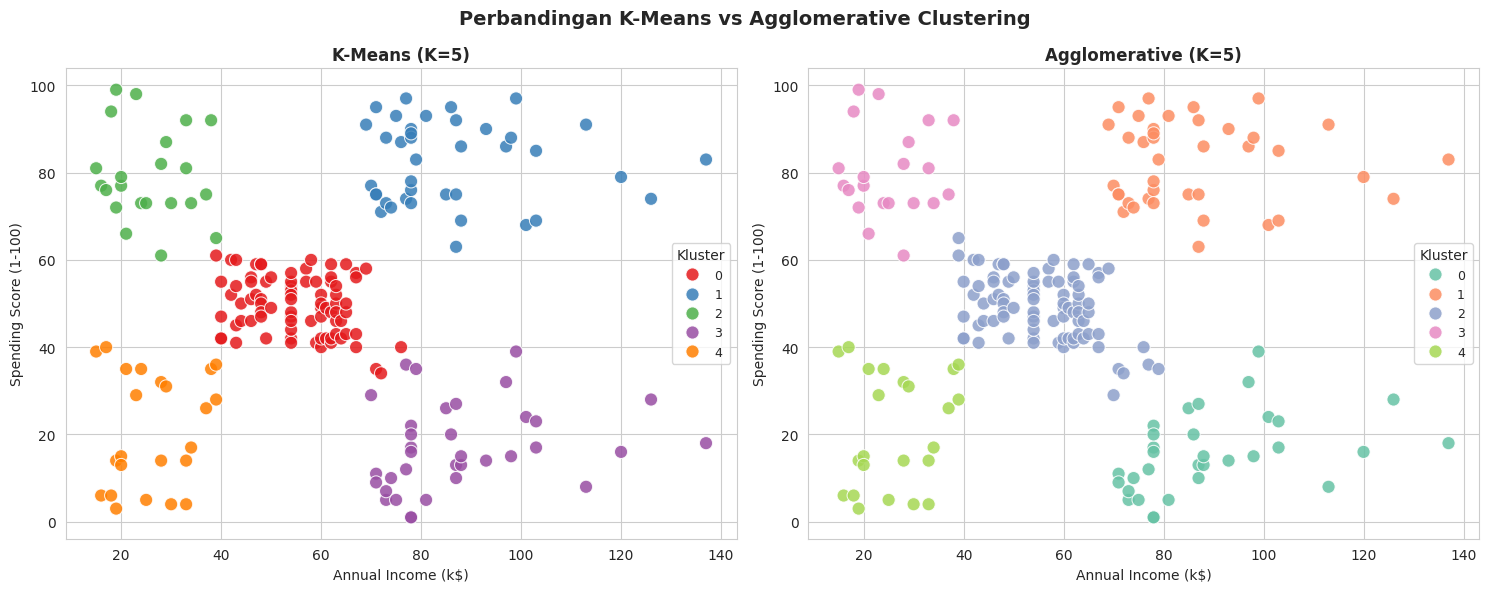

In [ ]:
# Membuat dua subplot untuk membandingkan hasil K-Means dan Agglomerative Clustering
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Melakukan iterasi untuk setiap jenis kluster (K-Means dan Agglomerative)
for ax_i, (col, title, pal) in enumerate([
    ('KMeans_Cluster', f'K-Means (K={k_final})', palette),
    ('Agglo_Cluster',  f'Agglomerative (K={k_final})', palette2)
]):


    sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                    hue=col, palette=pal, s=90, alpha=0.85, ax=axes[ax_i])
    axes[ax_i].set_title(title, fontsize=12, fontweight='bold')
    axes[ax_i].legend(title='Kluster', fontsize=9)

plt.suptitle('Perbandingan K-Means vs Agglomerative Clustering',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Analisis & Interpretasi Hasil Klaster

Berdasarkan rata-rata **Annual Income** dan **Spending Score** dari hasil K-Means:

| Kluster | Income (k$) | Spending Score | Jumlah | Segmen |
|---------|-------------|----------------|--------|--------|
| 0 | ~55 | ~50 | 81 | 🟡 Rata-rata (Moderat) |
| 1 | ~87 | ~82 | 39 | 🔴 Premium (High-High) |
| 2 | ~26 | ~79 | 22 | 🔵 Impulsif (Low-High) |
| 3 | ~88 | ~17 | 35 | 🟢 Hemat (High-Low) |
| 4 | ~26 | ~21 | 23 | 🟣 Terbatas (Low-Low) |

### Interpretasi Bisnis:
- **Kluster 1 (Premium):** Pelanggan berpotensi tinggi: program loyalitas eksklusif & produk premium
- **Kluster 2 (Impulsif):** Muda & suka belanja meski income rendah: promo flash sale & cicilan
- **Kluster 3 (Hemat):** Income tinggi tapi jarang belanja: perlu pendekatan personal & penawaran premium
- **Kluster 4 (Terbatas):** Fokus kebutuhan dasar: bundling & harga terjangkau
- **Kluster 0 (Rata-rata):** Segmen terbesar: membership & diskon reguler

### Kesimpulan:
> Kedua metode (K-Means & Agglomerative) menghasilkan klaster yang sangat serupa dengan Silhouette Score > 0.55, mengindikasikan klasterisasi yang baik. K=5 terbukti optimal dari dua pendekatan berbeda (Elbow + Silhouette).
